# BAB V — Implementasi dan Pengujian
## Identifikasi Biometrik Telapak Tangan Menggunakan Model Embedding

Notebook ini melatih **model embedding** telapak tangan. **Preprocessing (ROI)**, **augmentasi**, dan **perilaku fine-tuning** mengikuti notebook klasifikasi (palm_classification), sedangkan **evaluasi (cross-validation + EER)** dan **penanganan kiri/kanan tangan** mengikuti notebook palm_embedding.

1. **5.1 Proses ROI** — pipeline ROI palm_classification (grayscale + hapus background, Gaussian blur + Otsu, erosi/kontur, FFT/minima/rotasi). *(identik palm_classification)*
2. **5.2 Pelatihan Model Embedding** — EfficientNetB0 (transfer learning, base dibekukan), augmentasi & perilaku fine-tuning identik palm_classification; keluaran berupa **vektor embedding 128-D**. Indeks identitas & template dibangun **per tangan (kiri/kanan)** seperti palm_embedding.
3. **5.3 Pengujian Sistem** — **cross-validation** dengan skema per fold (enrolled / unknown / val), skor di-pool menjadi **EER ± 95% CI (bootstrap)**, AUC, Rank-1, FRR, dan OpenFA — sama seperti palm_embedding.
4. **5.4 Model Final & Ekspor** — latih ulang pada semua identitas, simpan .keras + TFLite + metadata.

> Perbedaan utama dengan palm_embedding: pelatihan tetap memakai **EfficientNet beku + kepala softmax "guru"** (gaya palm_classification), bukan ArcFace/progressive unfreezing. Namun evaluasi dan penanganan kiri/kanan tangan dibuat **sama** dengan palm_embedding.

> Catatan: setiap sel kode diberi komentar yang menjelaskan fungsi, nilai parameter/variabel, dan teknik yang dipakai.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# 5.1 Implementasi Proses ROI

Tujuan tahap ini adalah memperoleh citra **ROI (Region of Interest)** dari gambar telapak tangan. Proses melibatkan 3 tahap preprocessing yang kemudian dilanjutkan perhitungan untuk mendapatkan ROI.

## 5.1.1 Import Library (Proses ROI)

In [ ]:
!pip install "rembg==2.0.59" "onnxruntime==1.19.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.2 MB/s eta 0:00:00


In [2]:
# === Library untuk proses ROI ===
import os                              # membaca / menulis file
import csv                             # membaca / menulis file CSV
import numpy as np                     # operasi numerik yang efisien untuk pemrosesan data
import cv2                             # OpenCV: visi komputer & pemrosesan gambar
from PIL import Image                  # Pillow: membuka, memanipulasi, menyimpan gambar
from matplotlib import pyplot as plt   # visualisasi grafik (interaktif & statis)
from rembg import remove               # menghapus latar belakang gambar secara otomatis


# Helper kecil untuk menampilkan gambar grayscale dengan rapi
def show(img):
    """Menampilkan satu citra (grayscale) menggunakan matplotlib."""
    plt.imshow(img, cmap="gray")
    plt.axis("off")

## 5.1.2 Preprocessing-1 (Grayscale + Hapus Background)

Langkah: muat gambar → ambil dimensi → resize ke **480 x 640** → konversi ke **grayscale** → hapus background dengan `rembg`.

In [3]:
def preprocessing_1(image_path):
    """Preprocessing-1: resize, grayscale, dan hapus background.
    Mengembalikan output_image (PIL Image) hasil penghapusan background."""
    # Memuat gambar dari path
    img = cv2.imread(image_path)

    # Periksa apakah gambar berhasil dimuat
    if img is None:
        raise ValueError(f"Gambar tidak dapat dimuat. Pastikan path benar: {image_path}")

    # Mendapatkan tinggi (h) dan lebar (w) gambar asli
    h, w = img.shape[:2]

    # Mengubah ukuran gambar menjadi 480 x 640 piksel (interpolasi kubik agar halus)
    img_resized = cv2.resize(img, dsize=(480, 640), interpolation=cv2.INTER_CUBIC)

    # Mengubah gambar ke skala abu-abu (grayscale)
    img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Membuka gambar sebagai input untuk rembg
    input_image = Image.fromarray(img_resized)

    # Menghapus background dari gambar tangan secara otomatis
    output_image = remove(input_image)

    return output_image


# Contoh pemakaian (ganti dengan path gambar telapak tangan Anda):
# image_path = "dataset/sample_hand.jpg"
# output_image = preprocessing_1(image_path)
# show(np.array(output_image)); plt.title("Hasil Preprocessing-1"); plt.show()

## 5.1.3 Preprocessing-2 (Gaussian Blur + Otsu Thresholding)

Hasil preprocessing-1 dikonversi ke array OpenCV, tinggi gambar diperluas **+160 px** (80 atas + 80 bawah), lalu di-blur dengan **Gaussian Blur kernel 5x5** dan di-threshold dengan **Otsu**.

In [4]:
def preprocessing_2(output_image):
    """Preprocessing-2: Gaussian Blur + Otsu thresholding.
    Mengembalikan citra biner `th`."""
    # Konversi gambar PIL (hasil rembg) ke array OpenCV
    img_original = np.array(output_image)

    # Jika gambar belum grayscale (punya 3 channel), konversikan ke grayscale
    if len(img_original.shape) == 3:
        img_original = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)

    # Memperluas tinggi gambar sebanyak 160 piksel (80 di atas dan 80 di bawah)
    h, w = img_original.shape
    img = np.zeros((h + 160, w), np.uint8)   # kanvas hitam baru
    img[80:-80, :] = img_original            # tempel gambar asli di tengah

    # Menerapkan Gaussian Blur dengan kernel 5x5 (sigma=0 dihitung otomatis)
    blur = cv2.GaussianBlur(img, (5, 5), 0)

    # Menerapkan Otsu's thresholding -> menghasilkan citra biner (0 / 255)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return img, th


# Contoh pemakaian:
# img, th = preprocessing_2(output_image)
# show(th); plt.title("Hasil Preprocessing-2 (Otsu)"); plt.show()

## 5.1.4 Preprocessing-3 (Erosi dan Kontur)

Menghitung **pusat massa** dari momen citra biner, melakukan **erosi** dengan kernel 3x3, mengambil **boundary** (tepi), lalu mencari & menggambar **kontur**.

In [5]:
def preprocessing_3(img, th, visualize=True):
    """Preprocessing-3: hitung pusat massa, erosi, boundary, dan kontur.
    Mengembalikan (cnt, x_c, y_c) untuk dipakai pada perhitungan ROI."""
    # Menghitung momen dari citra biner `th`
    M = cv2.moments(th)
    h, w = img.shape

    # Koordinat pusat massa (centroid) dari citra biner:
    #   m10 / m00 -> koordinat x ; m01 / m00 -> koordinat y
    #   m00 merepresentasikan total intensitas piksel
    x_c = M['m10'] // M['m00']
    y_c = M['m01'] // M['m00']

    plt.figure(figsize=(15, 5))
    plt.subplot(121)
    show(th)
    plt.plot(x_c, y_c, 'bx', markersize=10)   # tandai pusat massa

    # Kernel 3x3 berbentuk plus untuk operasi erosi
    kernel = np.array([[0, 1, 0],
                       [1, 1, 1],
                       [0, 1, 0]]).astype(np.uint8)

    # Operasi erosi pada citra biner (iterasi = 1)
    erosion = cv2.erode(th, kernel, iterations=1)

    # Boundary (tepi objek) = citra biner asli - hasil erosi
    boundary = th - erosion

    # Mencari kontur pada citra boundary:
    #   RETR_TREE          -> simpan semua kontur + hierarki penuh
    #   CHAIN_APPROX_NONE  -> simpan SEMUA titik kontur
    cnt, _ = cv2.findContours(boundary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

    # Ubah gambar grayscale ke BGR agar kontur bisa digambar berwarna
    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cnt = cnt[0]   # ambil kontur pertama dari list kontur

    # Gambar kontur dengan warna merah (255,0,0), tebal garis 2
    img_cnt = cv2.drawContours(img_c, [cnt], 0, (255, 0, 0), 2)

    if visualize:
        plt.subplot(122)
        plt.plot(x_c, y_c, 'bx', markersize=10)
        show(img_cnt)
        plt.tight_layout()
        plt.show()

    return cnt, x_c, y_c

## 5.1.5 Perhitungan ROI — Analisis Frekuensi & Rotasi (FFT)

Kontur dianalisis dengan **Fourier Transform** untuk memisahkan frekuensi tinggi (noise) dan rendah (fitur utama). Fungsi jarak Euclidean (ED function) dihitung dari setiap titik kontur ke pusat massa, lalu di-*low-pass filter* dengan **cutoff = 15**.

In [6]:
def hitung_ed_function(cnt, x_c, y_c, cutoff=15):
    """Menghitung fungsi jarak Euclidean (ED) + low-pass filtering via FFT.
    Mengembalikan (cnt, dist_c, dist_c_1)."""
    # Susun koordinat kontur sebagai array 2D: kolom 0 = x, kolom 1 = y
    cnt = cnt.reshape(-1, 2)

    # Indeks titik kontur dengan jumlah koordinat (x + y) terkecil -> titik kiri-atas
    left_id = np.argmin(cnt.sum(-1))

    # Putar urutan kontur agar dimulai dari titik kiri-atas
    cnt = np.concatenate([cnt[left_id:, :], cnt[:left_id, :]])

    # Fungsi jarak Euclidean: jarak tiap titik kontur ke pusat massa (x_c, y_c)
    dist_c = np.sqrt(np.square(cnt - [x_c, y_c]).sum(-1))

    # Fast Fourier Transform (FFT) dari fungsi jarak
    f = np.fft.rfft(dist_c)

    # cutoff = 15 -> ambang frekuensi; komponen di atasnya dinolkan (low-pass filter)
    f_new = np.concatenate([f[:cutoff], 0 * f[cutoff:]])

    # Inverse FFT -> fungsi jarak yang halus (hanya frekuensi rendah)
    dist_c_1 = np.fft.irfft(f_new)

    # Visualisasi perbandingan fungsi jarak asli vs hasil rekonstruksi frekuensi rendah
    plt.figure(figsize=(15, 5))
    plt.grid()
    plt.plot(dist_c, label='Original ED function', color='r', linewidth='3', linestyle='--')
    plt.plot(dist_c_1, label='Low frequency reconstruction', color='b', linestyle='-')
    plt.legend()
    plt.show()

    return cnt, dist_c, dist_c_1

### Menentukan Minima dan Rotasi ROI

Titik **minima** dicari dari perubahan tanda turunan fungsi jarak. Dua minima terakhir (`v1`, `v2`) dipakai untuk menghitung sudut rotasi `theta`, citra diluruskan, lalu kotak **ROI** digambar dari koordinat sudut (ux, uy) dan (lx, ly).

In [7]:
def tentukan_roi(img, cnt, dist_c_1):
    """Mencari titik minima, menghitung rotasi, dan menggambar kotak ROI."""
    # Turunan pertama dari fungsi jarak halus untuk menemukan titik ekstrim
    derivative = np.diff(dist_c_1)

    # Perubahan tanda turunan -> menandai posisi titik ekstrim (minima/maxima)
    sign_change = np.diff(np.sign(derivative)) / 2

    # Ambil titik-titik kontur pada perubahan tanda positif (minima)
    minimas = cnt[np.where(sign_change > 0)[0]]

    # Dua titik minima yang dipakai untuk menghitung rotasi (minima terakhir & ke-3 dari belakang)
    v1, v2 = minimas[-1], minimas[-3]

    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    show(img)
    plt.plot(v1[0], v1[1], 'rx')
    plt.plot(v2[0], v2[1], 'bx')

    plt.subplot(132)
    # Sudut antara garis v1-v2 dan sumbu horizontal (dalam derajat)
    theta = np.arctan2((v2 - v1)[1], (v2 - v1)[0]) * 180 / np.pi
    print('The rotation of ROI is {:.02f}°'.format(theta))

    # Pusat rotasi = titik tengah antara v1 dan v2
    center = (int((v1[0] + v2[0]) // 2), int((v1[1] + v2[1]) // 2))

    # Matriks rotasi 2D (skala = 1) lalu putar gambar agar ROI lurus
    R = cv2.getRotationMatrix2D(tuple(center), theta, 1)
    h, w = img.shape
    img_r = cv2.warpAffine(img, R, (w, h))

    # Perbarui koordinat v1 & v2 sesuai rotasi
    v1 = (R[:, :2] @ v1 + R[:, -1]).astype(int)
    v2 = (R[:, :2] @ v2 + R[:, -1]).astype(int)
    plt.plot(v1[0], v1[1], 'rx')
    plt.plot(v2[0], v2[1], 'bx')
    show(img_r)

    # Koordinat sudut ROI: (ux, uy) kiri-atas dan (lx, ly) kanan-bawah
    ux = v1[0]
    uy = v1[1] + (v2 - v1)[0] // 3
    lx = v2[0]
    ly = v2[1] + 4 * (v2 - v1)[0] // 3

    # Gambar kotak ROI berwarna hijau (0,255,0)
    img_c = cv2.cvtColor(img_r, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(img_c, (lx, ly), (ux, uy), (0, 255, 0), 2)
    plt.subplot(133)
    show(img_c)
    plt.tight_layout()
    plt.show()

    # Potong ROI akhir dari citra yang sudah diluruskan
    roi = img_r[uy:ly, ux:lx]
    return roi

### Pipeline ROI End-to-End

Menggabungkan seluruh tahap 5.1.2 – 5.1.5 menjadi satu fungsi agar mudah dipanggil per gambar.

In [8]:
def ekstrak_roi(image_path):
    """Pipeline lengkap: dari gambar tangan mentah -> citra ROI."""
    output_image = preprocessing_1(image_path)           # grayscale + hapus background
    img, th = preprocessing_2(output_image)              # Gaussian blur + Otsu
    cnt, x_c, y_c = preprocessing_3(img, th)             # erosi + kontur
    cnt, dist_c, dist_c_1 = hitung_ed_function(cnt, x_c, y_c, cutoff=15)  # FFT
    roi = tentukan_roi(img, cnt, dist_c_1)               # minima, rotasi, crop ROI
    return roi


# Contoh: roi = ekstrak_roi("dataset/sample_hand.jpg")
# show(roi); plt.title("Gambar ROI Tangan"); plt.show()

---
# 5.2 Implementasi Pelatihan Model Embedding

Jaringan dilatih untuk menghasilkan **vektor embedding** (representasi ringkas tiap telapak tangan). Saat pelatihan dipakai **kepala klasifikasi softmax** sebagai "guru" agar embedding belajar memisahkan identitas; sesudahnya kepala dilepas dan hanya lapisan **embedding** yang dipakai.

Augmentasi, base model (EfficientNetB0 beku), optimizer (Adam 1e-4), loss (categorical_crossentropy), dan EarlyStopping dibuat **identik** palm_classification. Indeks identitas, template, serta opsi pemisahan **kiri/kanan tangan** mengikuti palm_embedding.

## 5.2.1 Konfigurasi

Semua parameter terpusat di sini: path data, parameter citra/model (mengikuti palm_classification), serta parameter **cross-validation, TTA, dan kiri/kanan tangan** (mengikuti palm_embedding).

In [9]:
import os, json, math, random, glob
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import roc_curve, auc

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# --- Path ---
RAW_DIR      = "/content/drive/MyDrive/Skripsi/dataset_mentah"   # data mentah: <orang>/*.jpg
ROI_DIR      = "/content/drive/MyDrive/Skripsi/dataset_roi_2"       # hasil ROI: <orang>/*.png
SAVE_DIR     = "/content/drive/MyDrive/Skripsi/models"            # tempat menyimpan model
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# --- Citra & Model (identik palm_classification) ---
IMG_SIZE  = (224, 224)   # ukuran input EfficientNet
BATCH     = 32           # batch size
EMBED_DIM = 128          # panjang vektor embedding

# --- Pelatihan (perilaku fine-tuning identik palm_classification) ---
LR          = 1e-4       # Adam learning rate 0.0001
EPOCHS      = 100        # jumlah epoch maksimum
ES_PATIENCE = 5          # EarlyStopping patience

# --- Penanganan kiri/kanan tangan (sama seperti palm_embedding.ipynb) ---
SPLIT_BY_HAND_TRAIN = False   # True -> kiri/kanan jadi kelas berbeda saat TRAIN (eval tetap per-orang)

# --- Evaluasi Cross-Validation (sama seperti palm_embedding.ipynb) ---
N_GALLERY       = 4      # citra per tangan untuk enrollment (template)
N_TEST_ENROLLED = 3      # identitas terdaftar (enrolled) per fold
N_TEST_UNKNOWN  = 3      # identitas asing (impostor) per fold
N_VAL_IDS       = 4      # identitas untuk validasi EER saat training
N_FOLDS         = 10     # jumlah fold
TTA_ROTATIONS   = [0.0, -6.0, 6.0]   # Test-Time Augmentation (rata-rata embedding atas rotasi kecil)
TARGET_FAR      = [0.001, 0.01]      # target FAR untuk pemilihan threshold
BOOTSTRAP_B     = 2000               # iterasi bootstrap untuk 95% CI

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 5.2.2 Bangun Dataset ROI (sekali jalan)

ROI diekstrak dari `RAW_DIR/<orang>/*` memakai pipeline **ekstrak_roi()** dari Bagian 5.1 (palm_classification) dan disimpan ke `ROI_DIR/<orang>/*.png`. Nama file dipertahankan agar penanda **kiri/kanan tangan** tetap terbaca oleh `hand_of()`. Tampilan plot dimatikan sementara selama proses batch agar tidak menggambar tiap gambar.

In [10]:
SKIP_IF_EXISTS = True   # jika ROI_DIR sudah berisi data, lewati ekstraksi ulang

def build_roi_dataset():
    # Bangun ROI_DIR/<orang>/*.png dari RAW_DIR memakai pipeline ROI palm_classification (ekstrak_roi).
    if SKIP_IF_EXISTS and os.path.isdir(ROI_DIR) and any(
            os.path.isdir(os.path.join(ROI_DIR, d)) for d in os.listdir(ROI_DIR)):
        print("ROI_DIR sudah berisi data; lewati ekstraksi.")
        return
    # Matikan tampilan plot selama batch (fungsi ROI palm_classification memang menggambar plot)
    _orig_show = plt.show
    plt.show = lambda *a, **k: None
    persons = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
    ok = miss = empty = 0
    for person in tqdm(persons, desc="ROI"):
        pdir = os.path.join(RAW_DIR, person)
        for fn in sorted(os.listdir(pdir)):
            if not fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                continue
            try:
                roi = ekstrak_roi(os.path.join(pdir, fn))   # pipeline ROI palm_classification (Bagian 5.1)
            except Exception:
                miss += 1; plt.close("all"); continue
            plt.close("all")
            if roi is None or getattr(roi, "size", 0) == 0:
                empty += 1; continue
            outdir = os.path.join(ROI_DIR, person)
            os.makedirs(outdir, exist_ok=True)
            # Pertahankan nama file (tanda kiri/kanan) -> simpan sebagai .png
            cv2.imwrite(os.path.join(outdir, os.path.splitext(fn)[0] + ".png"), roi)
            ok += 1
    plt.show = _orig_show
    print("Selesai. ok=", ok, "| gagal_ekstraksi=", miss, "| kosong=", empty)

build_roi_dataset()

ROI_DIR sudah berisi data; lewati ekstraksi.


In [11]:
# === Ekstrak ROI untuk orang tertentu saja (resume tanpa mengulang semua) ===
# Berguna saat proses build_roi_dataset() terhenti di tengah jalan.
# File ROI yang SUDAH ada akan dilewati, jadi aman dijalankan berkali-kali.

def build_roi_for(persons, overwrite=False):
    _orig_show = plt.show
    plt.show = lambda *a, **k: None          # matikan tampilan plot selama batch
    ok = miss = empty = skip = 0
    for person in tqdm(persons, desc="ROI(lanjut)"):
        pdir = os.path.join(RAW_DIR, person)
        if not os.path.isdir(pdir):
            print("Lewati (folder mentah tidak ada):", person); continue
        outdir = os.path.join(ROI_DIR, person)
        os.makedirs(outdir, exist_ok=True)
        for fn in sorted(os.listdir(pdir)):
            if not fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                continue
            outpath = os.path.join(outdir, os.path.splitext(fn)[0] + ".png")
            if (not overwrite) and os.path.exists(outpath):
                skip += 1; continue          # sudah ada -> lewati (resume)
            try:
                roi = ekstrak_roi(os.path.join(pdir, fn))   # pipeline ROI palm_classification
            except Exception:
                miss += 1; plt.close("all"); continue
            plt.close("all")
            if roi is None or getattr(roi, "size", 0) == 0:
                empty += 1; continue
            cv2.imwrite(outpath, roi); ok += 1
    plt.show = _orig_show
    print("Selesai. baru=", ok, "| sudah_ada(dilewati)=", skip, "| gagal_ekstraksi=", miss, "| kosong=", empty)

# Daftar orang (urutan sama seperti build_roi_dataset)
persons_all = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
print("Total orang:", len(persons_all))

# --- Proses HANYA orang terakhir (27/28 -> indeks ke-27) ---
target = persons_all[27]            # atau: persons_all[-1]
print("Memproses:", target)
build_roi_for(persons_all)   # resume seluruh dataset, hanya yang belum ada yang diproses

Total orang: 28
Memproses: Wildan ihza mahbubi


ROI(lanjut):  36%|███▌      | 10/28 [07:57<14:32, 48.46s/it]

The rotation of ROI is 44.64°
The rotation of ROI is 45.00°


ROI(lanjut):  79%|███████▊  | 22/28 [13:34<03:03, 30.58s/it]

The rotation of ROI is 65.32°
The rotation of ROI is 53.26°


...

The rotation of ROI is 171.52°


ROI(lanjut):  96%|█████████▋| 27/28 [16:10<00:27, 27.45s/it]

The rotation of ROI is -7.41°
The rotation of ROI is -6.71°
The rotation of ROI is -7.33°
The rotation of ROI is -6.34°
The rotation of ROI is -7.89°


ROI(lanjut): 100%|██████████| 28/28 [16:30<00:00, 35.39s/it]

The rotation of ROI is 23.39°
Selesai. baru= 6 | sudah_ada(dilewati)= 700 | gagal_ekstraksi= 409 | kosong= 5


## 5.2.3 Indeks Identitas, Penanganan Kiri/Kanan & Helper Embedding (TTA)

Bagian ini sama seperti palm_embedding: menyusun daftar identitas, fungsi `hand_of()` untuk menandai tangan kiri/kanan dari nama file, serta `embed_paths()` yang menghitung embedding ber-L2-norm dengan **Test-Time Augmentation (TTA)** (rata-rata embedding atas rotasi kecil).

In [12]:
# Penanganan kiri/kanan tangan (sama seperti palm_embedding.ipynb)
def hand_of(filename):
    # Tentukan tangan (L/R) dari nama file; mis. "orang_01_L.png" -> "L".
    parts = os.path.splitext(filename)[0].split("_")
    if len(parts) >= 3 and parts[2].upper() in ("L", "R"):
        return parts[2].upper()
    f = filename.lower()
    if any(k in f for k in ["left", "kiri"]):  return "L"
    if any(k in f for k in ["right", "kanan"]): return "R"
    return "X"

In [13]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def _list_imgs(d):
    return [os.path.join(d, f) for f in os.listdir(d)
            if os.path.isfile(os.path.join(d, f)) and f.lower().endswith(IMG_EXTS)]

# Bangun peta identitas -> daftar file. Mendukung DUA tata letak folder ROI:
#   (a) ROI_DIR/<orang>/*.png
#   (b) ROI_DIR/<split>/<orang>/*.png  (mis. train/val/test) -> otomatis digabung per orang
ID_TO_FILES = {}
_top = sorted([d for d in os.listdir(ROI_DIR) if os.path.isdir(os.path.join(ROI_DIR, d))])
for d in _top:
    dpath = os.path.join(ROI_DIR, d)
    direct = _list_imgs(dpath)
    if direct:                       # (a) d adalah folder orang (langsung berisi citra)
        ID_TO_FILES.setdefault(d, []).extend(direct)
    else:                            # (b) d adalah split -> turun satu level ke folder orang
        for sub in sorted(os.listdir(dpath)):
            subp = os.path.join(dpath, sub)
            if os.path.isdir(subp):
                ID_TO_FILES.setdefault(sub, []).extend(_list_imgs(subp))

ID_TO_FILES = {k: sorted(v) for k, v in ID_TO_FILES.items() if v}
ALL_IDS = sorted(ID_TO_FILES)
print('Total identitas:', len(ALL_IDS),
      '| total citra:', sum(len(v) for v in ID_TO_FILES.values()))
_need = N_TEST_ENROLLED + N_TEST_UNKNOWN + N_VAL_IDS + 1
assert len(ALL_IDS) >= _need, (
    'Identitas terbaca %d, butuh minimal %d. ROI_DIR kosong atau struktur folder salah. '
    'Pastikan ROI sudah dibuat (sel 5.2.2) dan tiap orang punya foldernya sendiri.' % (len(ALL_IDS), _need))

def imgs_of(label):
    return ID_TO_FILES.get(label, [])

def load_img(path):
    return cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), IMG_SIZE).astype(np.float32)

def _rotate(img, deg):
    if deg == 0:
        return img
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2.0, h/2.0), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

def embed_paths(model, paths, tta=None, batch=64):
    if tta is None:
        tta = TTA_ROTATIONS
    if len(paths) == 0:
        return np.zeros((0, EMBED_DIM), np.float32)
    base = [load_img(p) for p in paths]
    accum = np.zeros((len(paths), EMBED_DIM), np.float32)
    for deg in tta:
        e = model.predict(np.stack([_rotate(im, deg) for im in base]), verbose=0, batch_size=batch)
        accum += e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)
    accum /= len(tta)
    return (accum / (np.linalg.norm(accum, axis=1, keepdims=True) + 1e-9)).astype(np.float32)

Total identitas: 28 | total citra: 706


## 5.2.4 Model, Augmentasi & Rutin Pelatihan

Model embedding = EfficientNetB0 (beku) + GlobalAveragePooling + Dropout(0.3) + Dense(128). Saat pelatihan ditambah kepala softmax sebagai "guru". Rutin `fit_model()` melatih satu model per kumpulan identitas dengan perilaku **identik palm_classification** (Adam 1e-4, categorical_crossentropy, EarlyStopping). Indeks pelatihan mendukung opsi **kiri/kanan tangan** (`SPLIT_BY_HAND_TRAIN`) seperti palm_embedding.

In [14]:
def make_augment():
    # Augmentasi identik palm_classification: flip horizontal + rotasi 10% + zoom 10%
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="augment")

def build_embedding_model(embed_dim=EMBED_DIM):
    # EfficientNetB0 dibekukan (transfer learning) -> perilaku fine-tuning identik palm_classification
    backbone = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
    backbone.trainable = False
    inp = Input(IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inp)   # normalisasi khas EfficientNet
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)                                     # dropout 30% (regularisasi)
    x = layers.Dense(embed_dim, name="embedding")(x)               # lapisan embedding 128-D
    return models.Model(inp, x, name="embedding_model"), backbone

def build_train_model(num_classes):
    # Model pelatihan: citra -> augmentasi -> embedding -> kepala softmax ("guru")
    em, bb = build_embedding_model()
    img_in = Input(IMG_SIZE + (3,), name="image")
    emb = em(make_augment()(img_in))
    out = layers.Dense(num_classes, activation="softmax", name="klasifikasi")(emb)
    return models.Model(img_in, out, name="trainer"), em

In [15]:
def _ds_from(paths, labels, num_classes):
    # tf.data dari daftar path -> (citra 0-255 float32, one-hot)
    def _load(p, y):
        img = tf.cast(tf.image.resize(tf.io.decode_png(tf.io.read_file(p), channels=3), IMG_SIZE), tf.float32)
        return img, tf.one_hot(y, num_classes)
    assert len(paths) > 0, 'Tidak ada citra untuk train_ids ini. Cek ROI_DIR dan struktur folder (<orang>/*.png).'
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)).shuffle(max(1, len(paths)), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

def build_train_index(train_ids, split_by_hand):
    # Susun daftar kelas + file per kelas. split_by_hand=True -> kiri/kanan jadi kelas terpisah.
    classes, pbc = [], {}
    for pid in train_ids:
        files = imgs_of(pid)
        if split_by_hand:
            g = {}
            for f in files:
                g.setdefault(hand_of(os.path.basename(f)), []).append(f)
            for h, fs in g.items():
                c = pid + "__" + h; classes.append(c); pbc[c] = fs
        else:
            classes.append(pid); pbc[pid] = files
    return classes, pbc

class EERValidation(tf.keras.callbacks.Callback):
    # Hitung EER pada identitas validasi tiap akhir epoch -> dipakai EarlyStopping (val_eer)
    def __init__(self, em, val_ids, n_gallery=N_GALLERY):
        super().__init__(); self.em = em
        self.files = {p: imgs_of(p) for p in val_ids}; self.n_gallery = n_gallery
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        tem, prb = {}, []
        for p, fs in self.files.items():
            fs2 = list(fs); random.Random(SEED).shuffle(fs2)
            g, q = fs2[:self.n_gallery], fs2[self.n_gallery:]
            if not g or not q:
                continue
            t = embed_paths(self.em, g, tta=[0.0]).mean(0); tem[p] = t / (np.linalg.norm(t) + 1e-9)
            for v in embed_paths(self.em, q, tta=[0.0]):
                prb.append((v, p))
        if len(tem) < 2 or not prb:
            logs["val_eer"] = 1.0; return
        ids = list(tem); M = np.stack([tem[i] for i in ids]); gen, imp = [], []
        for v, tp in prb:
            sims = M @ v
            for i, idp in enumerate(ids):
                (gen if idp == tp else imp).append(float(sims[i]))
        fpr, tpr, _ = roc_curve(np.r_[np.ones(len(gen)), np.zeros(len(imp))], np.r_[gen, imp])
        fnr = 1 - tpr; i = int(np.nanargmin(np.abs(fpr - fnr)))
        logs["val_eer"] = float((fpr[i] + fnr[i]) / 2.0)

def fit_model(train_ids, val_ids=None, split_by_hand=SPLIT_BY_HAND_TRAIN):
    # Latih SATU model embedding. Perilaku fine-tuning identik palm_classification
    # (EfficientNet beku, Adam 1e-4, categorical_crossentropy, EarlyStopping).
    tf.keras.backend.clear_session()
    classes, pbc = build_train_index(train_ids, split_by_hand)
    nc = len(classes); idx = {c: i for i, c in enumerate(classes)}
    paths, labels = [], []
    for c in classes:
        for f in pbc[c]:
            paths.append(f); labels.append(idx[c])
    ds = _ds_from(paths, labels, nc)
    trainer, em = build_train_model(nc)
    trainer.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    cbs = []
    if val_ids:
        # Validasi memakai EER (sesuai skema cross-validation palm_embedding)
        cbs.append(EERValidation(em, val_ids))
        cbs.append(tf.keras.callbacks.EarlyStopping(monitor="val_eer", mode="min",
                                                    patience=ES_PATIENCE, restore_best_weights=True))
    trainer.fit(ds, epochs=EPOCHS, callbacks=cbs, verbose=0)
    return em

---
# 5.3 Pengujian Sistem (Cross-Validation)

Pengujian memakai skema **cross-validation** seperti palm_embedding: tiap fold membagi identitas menjadi train / enrolled / unknown / val, model dilatih ulang per fold, lalu skor genuine/impostor di-pool untuk menghitung **EER ± 95% CI**.

## 5.3.1 Evaluasi per Fold (enroll + probe + unknown)

Untuk tiap identitas terdaftar, template dibangun **per tangan (kiri/kanan)**; pencocokan memakai **MAX cosine** terhadap semua template. Identitas *unknown* dipakai sebagai impostor untuk skenario open-set. *(identik palm_embedding)*

In [16]:
def evaluate_fold(em, enrolled_ids, unknown_ids):
    templates, probes = {}, []
    for pid in enrolled_ids:
        by_hand = {}
        for f in imgs_of(pid):
            by_hand.setdefault(hand_of(os.path.basename(f)), []).append(f)
        temps, pf = [], []
        for h, fs in by_hand.items():
            fs = list(fs); random.Random(SEED).shuffle(fs)
            g, q = fs[:N_GALLERY], fs[N_GALLERY:]
            if g:
                t = embed_paths(em, g).mean(0); temps.append(t / (np.linalg.norm(t) + 1e-9))
            pf += q
        if temps:
            templates[pid] = np.stack(temps)
        for v in embed_paths(em, pf):
            probes.append((v, pid))
    persons = list(templates)
    def ps(v, pid):
        return float(np.max(templates[pid] @ v))
    gen, imp, probe_best = [], [], []
    for v, tp in probes:
        sc = {pid: ps(v, pid) for pid in persons}
        for pid in persons:
            (gen if pid == tp else imp).append(sc[pid])
        bp = max(sc, key=sc.get); probe_best.append((sc[bp], bp == tp))
    unk_imp, unk_max = [], []
    for pid in unknown_ids:
        for v in embed_paths(em, imgs_of(pid)):
            s = [ps(v, q) for q in persons]; unk_imp += s; unk_max.append(max(s))
    return dict(gen=gen, imp=imp + unk_imp, probe_best=probe_best, unk_max=unk_max)

## 5.3.2 Cross-Validation Loop (pooled EER ± 95% CI)

Menjalankan seluruh fold, mem-pool skor, lalu melaporkan **EER per-fold (mean ± 95% CI)**, **EER pooled + bootstrap CI**, **AUC**, kurva ROC, serta **Rank-1 / FRR / OpenFA** pada target FAR. *(identik palm_embedding)*

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fold 1 / 10 | train= 18 | EER=15.94%
Fold 2 / 10 | train= 18 | EER=3.83%
Fold 3 / 10 | train= 18 | EER=9.11%
Fold 4 / 10 | train= 18 | EER=15.38%
Fold 5 / 10 | train= 18 | EER=13.30%
Fold 6 / 10 | train= 18 | EER=19.04%
Fold 7 / 10 | train= 18 | EER=11.90%
Fold 8 / 10 | train= 18 | EER=0.67%
Fold 9 / 10 | train= 18 | EER=17.00%
Fold 10 / 10 | train= 18 | EER=15.67%

==== HASIL CROSS-VALIDATION ====
Fold=10 | identitas teruji=26/28
EER per-fold: mean=12.18% +/-3.70% (95%CI) | min=0.67% max=19.04%
EER pooled  : 11.45% | bootstrap 95%CI=[9.28%, 13.66%] | AUC=0.9494

Threshold pada target FAR (skor pooled):
  FAR<=0.1% -> thr=0.9361 | Rank-1=72.86% | FRR=26.96% | OpenFA=0.27%
  FAR<=1.0% -> thr=0.8966 | Rank-1=79.42% | FRR=20.40% | OpenFA=4.19%


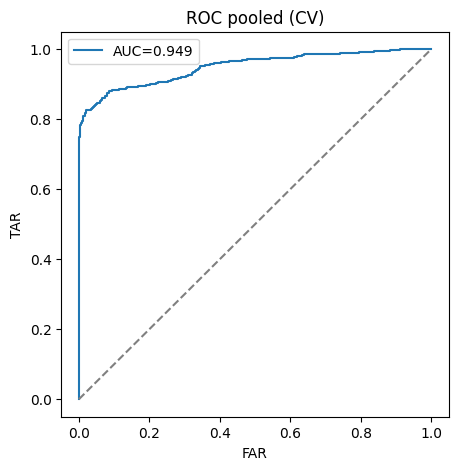

In [17]:
def make_folds(all_ids, k, n_enr, n_unk, n_val, seed=SEED):
    fl = []
    for f in range(k):
        ids = list(all_ids); random.Random(seed + f).shuffle(ids)
        a, b, c = n_enr, n_enr + n_unk, n_enr + n_unk + n_val
        fl.append(dict(enrolled=ids[:a], unknown=ids[a:b], val=ids[b:c], train=ids[c:]))
    return fl

def compute_eer(gen, imp):
    fpr, tpr, thr = roc_curve(np.r_[np.ones(len(gen)), np.zeros(len(imp))], np.r_[gen, imp])
    fnr = 1 - tpr; i = int(np.nanargmin(np.abs(fpr - fnr)))
    return float(auc(fpr, tpr)), float((fpr[i] + fnr[i]) / 2.0), fpr, tpr, thr

def bootstrap_eer(gen, imp, B=BOOTSTRAP_B, seed=SEED):
    rng = np.random.default_rng(seed); gen = np.asarray(gen); imp = np.asarray(imp); out = []
    for _ in range(B):
        _, e, _, _, _ = compute_eer(rng.choice(gen, len(gen), True), rng.choice(imp, len(imp), True))
        out.append(e)
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

folds = make_folds(ALL_IDS, N_FOLDS, N_TEST_ENROLLED, N_TEST_UNKNOWN, N_VAL_IDS)
G, I, per_fold_eer, all_pb, all_unk, tested = [], [], [], [], [], set()
for k, fd in enumerate(folds):
    em = fit_model(fd['train'], fd['val'])
    r = evaluate_fold(em, fd['enrolled'], fd['unknown'])
    g, im = np.array(r['gen']), np.array(r['imp'])
    _, eer, _, _, _ = compute_eer(g, im); per_fold_eer.append(eer)
    G.append(g); I.append(im); all_pb += r['probe_best']; all_unk += r['unk_max']
    tested |= set(fd['enrolled']) | set(fd['unknown'])
    print('Fold', k + 1, '/', N_FOLDS, '| train=', len(fd['train']), '| EER=%.2f%%' % (eer * 100))

G, I = np.concatenate(G), np.concatenate(I)
AUC, EER, fpr, tpr, thr = compute_eer(G, I); lo, hi = bootstrap_eer(G, I); pf = np.array(per_fold_eer)
print('\n==== HASIL CROSS-VALIDATION ====')
print('Fold=%d | identitas teruji=%d/%d' % (N_FOLDS, len(tested), len(ALL_IDS)))
print('EER per-fold: mean=%.2f%% +/-%.2f%% (95%%CI) | min=%.2f%% max=%.2f%%' % (
    pf.mean() * 100, 1.96 * pf.std(ddof=1) / np.sqrt(len(pf)) * 100, pf.min() * 100, pf.max() * 100))
print('EER pooled  : %.2f%% | bootstrap 95%%CI=[%.2f%%, %.2f%%] | AUC=%.4f' % (EER * 100, lo * 100, hi * 100, AUC))

def thr_at_far(ft):
    ok = np.where(fpr <= ft)[0]; return float(thr[ok[-1] if len(ok) else 0])

print('\nThreshold pada target FAR (skor pooled):')
for ft in TARGET_FAR:
    T = thr_at_far(ft)
    rank1 = np.mean([(s >= T and ok) for s, ok in all_pb])
    frr = np.mean([s < T for s, _ in all_pb])
    openfa = np.mean([s >= T for s in all_unk]) if all_unk else 0.0
    print('  FAR<=%.1f%% -> thr=%.4f | Rank-1=%.2f%% | FRR=%.2f%% | OpenFA=%.2f%%' % (
        ft * 100, T, rank1 * 100, frr * 100, openfa * 100))

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='AUC=%.3f' % AUC); plt.plot([0, 1], [0, 1], '--', c='gray')
plt.xlabel('FAR'); plt.ylabel('TAR'); plt.title('ROC pooled (CV)'); plt.legend(); plt.show()

---
# 5.4 Latih Model Final (semua identitas) & Ekspor

Cross-validation sudah memberi estimasi performa yang jujur, sehingga model final dilatih pada **semua identitas**, lalu diekspor ke `.keras`, **TFLite (float32)**, dan `model_metadata.json` (termasuk threshold operasional).

In [18]:
# CV sudah memberi estimasi jujur; model final dilatih pada SEMUA identitas.
embedding_model = fit_model(ALL_IDS, val_ids=ALL_IDS[:N_VAL_IDS])
OPERATING_FAR = max(TARGET_FAR)
OPERATING_THRESHOLD = thr_at_far(OPERATING_FAR)
print("OPERATING_THRESHOLD =", round(OPERATING_THRESHOLD, 4))

os.makedirs(SAVE_DIR, exist_ok=True)
embedding_model.save(os.path.join(SAVE_DIR, "palm_embedding.keras"))

# Ekspor TFLite (float32 = akurasi terbaik)
conv = tf.lite.TFLiteConverter.from_keras_model(embedding_model)
open(os.path.join(SAVE_DIR, "palm_embedding.tflite"), "wb").write(conv.convert())

meta = {
    "embedding_dim": EMBED_DIM,
    "img_size": list(IMG_SIZE),
    "input_range": "0-255 float32 (preprocess_input EfficientNet di dalam model)",
    "similarity": "cosine L2-norm",
    "operating_threshold": OPERATING_THRESHOLD,
    "operating_far": OPERATING_FAR,
    "cv_eer_pooled": EER,
    "cv_eer_ci95": [lo, hi],
    "cv_auc": AUC,
    "tta_rotations": TTA_ROTATIONS,
    "split_by_hand_train": SPLIT_BY_HAND_TRAIN,
    "preprocessing": "ROI palm_classification (rembg + Otsu + FFT/rotasi) -> resize 224",
}
json.dump(meta, open(os.path.join(SAVE_DIR, "model_metadata.json"), "w"), indent=2)
print(json.dumps(meta, indent=2))

OPERATING_THRESHOLD = 0.8966
Saved artifact at '/tmp/tmp9yhtt61d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 128), dtype=tf.float32, name=None)
Captures:
  132273931169488: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132273931170256: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132273626163216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679254736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679257232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679258384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679255120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679258000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273679253776: TensorSpec(sha